<div style="width: 100%; overflow: hidden;">
    <a href="http://www.uc.pt/fctuc/dei/">
    <div style="display: block;margin-left: auto;margin-right: auto; width: 50%;"><img src="https://eden.dei.uc.pt/~naml/images_ecos/dei25.png"  /></div>
    </a>
</div>

In [1134]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, accuracy_score, mean_squared_error, r2_score
import matplotlib.pyplot as plt

<h2><font color='#3498db'>1. Introduction</font></h2>
In the previous exercise sheet we saw that of the main limitations of perceptrons arises from this theorem in that they are unable to learn complex patterns that are not linearly separable. To address this, multilayer perceptrons (MLPs) were introduced, consisting of multiple layers of perceptrons sequentially aranged, so that the output of the ith layer is the input of layer i+1. 

The objective of this exercise is for you to implement and test a Artificial Neural Network (ANN) with one single layer. An example of such network can be seen in the figure bellow.

<center> 
<img width="250" height="250" src="ann.png"/>
<br>
Artificial Neural Network with one hidden layer </center>
<br>
<br>

We will assume that there are $n$ input nodes, plus the bias, $h$ hidden nodes, also plus a bias, and $o$ output nodes. We will assume a fully connected arquitecture, i.e., all neurons connect to all neurons in the next layer. As such there will be $(n+1) * h$ weights between the input and the hidden layer and  $(h+1) * o$ weights between the hidden layer and the output. We will assume that the bias values are equal to 1.

The algorithm described could have any number of hidden layers, in which case there might be different values of $h$, and we would require an extra set of weights for the hidden layers.

Assume the following:
- $x$ is an array with the inputs
- $w_1$ is the array with the weights from the input layer to the hidden layer
- $w_2$ is the array with the weights from the hidden layer to the output layer


### 1.1 The Algorithm

##### Initialisation 
- Initialise two arrays of weights $w_1$ and $w_2$ to small random numbers. They can be positive or negative

##### Training
- repeat
    - **Forwards pass**
        - compute the outputs of the hidden layer $$z_1 = \phi(x \cdot w_1)$$  
        - compute the outputs of the output layer $$\hat{y}=f(z_1 \cdot w_2)$$
    - **Backwards pass**
        - compute the error at the output layer: $$\delta_o=(y - \hat{y})f'(\hat{y})$$
        - compute the error at the hidden layer: $$\delta_h=f'(z_1) * (\delta_o \cdot w_2^T) $$
        - update the weights of the output layer: $$\Delta w_2 = (z_1^T \cdot \delta_o) \\ w_2=w_2 - \eta*\Delta w_2$$
        - update the weights of the hidden layer: $$\Delta w_1 = (x^T \cdot \delta_h) \\ w_1=w_1 - \eta*\Delta w_1$$
           

            




<h2><font color='#3498db'>2. Multi-Layered Perceptron Code</font></h2>
Now it is time for you to code a Multi-Layered Perceptron Code. Using the information above and the input data, develop a class named `MultiLayerPerceptron` that learns based on a set of labeled examples.

Since we are dealing mostly with matrix operations, I recommend that you use the `Numpy`numerical library for Python. this library provides us with several methods for matrix the manipulations, such as the Dot product: https://numpy.org/doc/stable/reference/generated/numpy.dot.html


Bellow your can find the implementation of two activation functions (and their derivatives) commonly used in ANNs.

In [1135]:
def sigmoid(x, der=False):
    if (der==True) : #derivative 
        f = 1/(1+ np.exp(-x))*(1-1/(1+ np.exp(- x)))
    else : # sigmoid
        f = 1/(1+ np.exp(-x))
    return f

# We may employ the Rectifier Linear Unit (ReLU)
def relu(x, der=False):
    if (der == True): # the derivative of the ReLU is the Heaviside Theta
        f = np.heaviside(x, 1)
    else :
        f = np.maximum(x, 0)
    
    return f

<h3><font color='#6A30BB'>Exercise #2.1 </font></h3>
Code the MultiLayerPerceptron


In [1136]:
class MultiLayerPerceptron:
    def __init__(self, number_of_inputs, n_targets, n_hidden, number_of_iterations=1000, learning_rate=0.01, output_type='relu'):
        # Network Parameters
        self.number_of_iterations = number_of_iterations  # Number of iterations for the training
        self.learning_rate = learning_rate # Learning rate for the weight updates
        self.number_of_inputs = number_of_inputs # Number of inputs to the network
        self.number_of_outputs = n_targets # Number of outputs from the network
        self.n_hidden = n_hidden # Number of hidden neurons in the hidden layer
        self.output_type = output_type # Type of output activation function (sigmoid or relu)

        self.loss_history = []  # Store loss values for each iteration

        #Weight Initialisation
        self.weights1 = (np.random.rand(self.number_of_inputs+1,self.n_hidden)-0.5)*2/np.sqrt(self.number_of_inputs)  # Weights between input and hidden layer
        self.weights2 = (np.random.rand(self.n_hidden+1,self.number_of_outputs)-0.5)*2/np.sqrt(self.n_hidden) # Weights between hidden and output layer
    
    def add_bias(self, inputs):
        """
            The bias is a parameter that is added to the weighted sum of the inputs before applying the activation function. 
            Its purpose is to provide an additional degree of freedom to the model, allowing it to shift the activation function 
            to the left or right. 
            To simplify the implementation of the perceptron (or the neural networks) a bias with the value of 1 is concatenated to every input vector.
            This way the bias term can be included in the dot product operation between the weights and the inputs. This makes it possible to handle the bias 
            as part of the weight matrix. Without this, the bias would need to be added explicitly as a separate step after computing the weighted sum of the inputs.
            For example, consider the inputs for the logical OR:
            [   [1. 1.]
                [1. 0.]
                [0. 1.]
                [0. 0.]
            ]
        The bias will be added as a third input, and the final set of inputs will be:
            [   [1. 1. 1.]
                [1. 0. 1.]
                [0. 1. 1.]
                [0. 0. 1.]
            ]
        """
        return np.concatenate((inputs,np.ones((inputs.shape[0],1))),axis=1)
    
    # The predict function is used to make predictions on new data using the trained model.
    # It takes the input data as an argument, adds a bias term to it, and then performs forward propagation through
    # the network to obtain the final output.
    # The output of the predict function is the final output of the network after applying the activation function.
    # The predict function does not perform any training or weight updates; it is only used for inference.
    def predict(self, inputs):
        inputs = self.add_bias(inputs)
        return self.forward_propagation(inputs)[1] # Only return the final output
    
    # The forward_propagation function is responsible for computing the output of the network given the input data.
    # It takes the input data as an argument, computes the weighted sum of inputs to the hidden layer, applies the
    # activation function, and then computes the weighted sum of hidden layer outputs to the output layer.
    # The output of the forward_propagation function is the final output of the network after applying the activation
    # function.
    def forward_propagation(self, inputs):
        ## YOUR CODE HERE ##
        inputs_hidden = np.dot(inputs, self.weights1) # Weighted sum of inputs to hidden layer
        outputs_hidden = relu(inputs_hidden) # Activation function for hidden layer

        outputs_hidden = self.add_bias(outputs_hidden) # Add bias to hidden layer outputs

        outputs_final = np.dot(outputs_hidden, self.weights2) # Weighted sum of hidden layer outputs to output layer
        if self.output_type == 'relu':
            outputs_final = relu(outputs_final)
        elif self.output_type == 'sigmoid':
            outputs_final = sigmoid(outputs_final) # Activation function for output layer

        return outputs_hidden, outputs_final

    def train(self, training_inputs, targets):
        #Add the Bias to the Input Matrix as as a fixed input.
        training_inputs = self.add_bias(training_inputs)
        
        for n in range(self.number_of_iterations):
            ## YOUR CODE HERE ##
            outputs_hidden, outputs_final = self.forward_propagation(training_inputs) # Forward propagation

            if self.output_type == 'sigmoid':
                error_final = (targets - outputs_final) * sigmoid(outputs_final, der=True)
            elif self.output_type == 'relu':
                error_final = (targets - outputs_final) * relu(outputs_final, der=True)
                
            error_hidden = relu(outputs_hidden[:, :-1], der=True) * np.dot(error_final, self.weights2[:-1].T) # Error at hidden layer

            self.weights2 -= self.learning_rate * np.dot(outputs_hidden.T, error_final) # Update weights between hidden and output layer
            self.weights1 -= self.learning_rate * np.dot(training_inputs.T, error_hidden) # Update weights between input and hidden layer

            # Store loss (MSE)
            loss = np.mean((targets - outputs_final) ** 2)
            self.loss_history.append(loss)

    def plot_loss(self):
        plt.plot(self.loss_history)
        plt.xlabel("Iterations")
        plt.ylabel("Loss (MSE)")
        plt.title("Training Loss over Time")
        plt.show()

<h3><font color='#6A30BB'>Exercise #2.2 </font></h3>
Now let's go back to the problem where the Perceptron failed. Train the MLP to learn the XOR Logical Function.

Predictions:  [1. 1. 1. 1.]
Rounded Predictions:  [1. 1. 1. 1.]


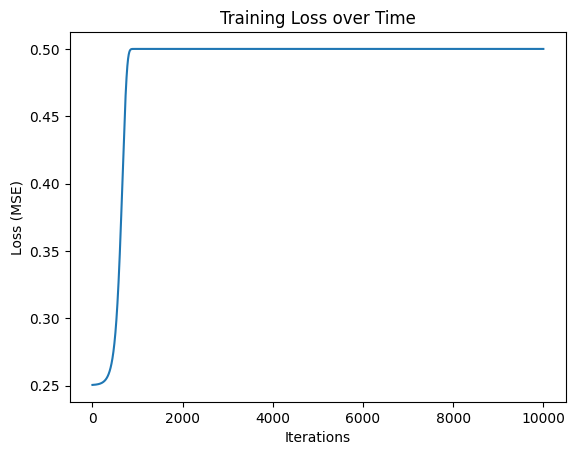

In [1137]:
# Logical XOR 
training_inputs = np.array([[1, 1], [1, 0], [0, 1], [0, 0]])
labels = np.array([[0], [1], [1], [0]])

## YOUR CODE HERE ##
mlp = MultiLayerPerceptron(number_of_inputs=2, n_targets=1, n_hidden=2, output_type='sigmoid', number_of_iterations=10000, learning_rate=0.01)
mlp.train(training_inputs, labels)
outputs = mlp.predict(training_inputs)
print("Predictions: ", outputs.flatten())
rounded_preds = np.round(outputs)
print("Rounded Predictions: ", rounded_preds.flatten())

mlp.plot_loss()

<h3><font color='#6A30BB'>Exercise #2.3 </font></h3>
Evaluate the capacity of the MLP to learn the XOR function. How close did it get to the perfect answer?

In [1138]:
# Logical XOR 

## YOUR CODE HERE ##
mse = np.mean((labels - outputs) ** 2)
print(f"\nMean Squared Error (MSE): {mse:.6f}")

accuracy = accuracy_score(labels, rounded_preds)
print(f"Accuracy: {accuracy:.2%}")


Mean Squared Error (MSE): 0.500000
Accuracy: 50.00%


<h3><font color='#6A30BB'>Exercise #3 </font></h3>
Lets evaluate the performance of your model in a dataset beyond the binary ones. In this case we are going to classfy the iris dataset.

The Iris dataset was used in R.A. Fisher's classic 1936 paper, The Use of Multiple Measurements in Taxonomic Problems, and can also be found on the UCI Machine Learning Repository.

It includes three iris species with 50 samples each as well as some properties about each flower. One flower species is linearly separable from the other two, but the other two are not linearly separable from each other.

The columns in this dataset are:

- SepalLength (cm)
- SepalWidth (cm)
- PetalLength (cm)
- PetalWidth (cm)
- Species

Let's start by loading and preparing the dataset.

In [1139]:
from sklearn.datasets import load_iris
iris = load_iris()
X = iris.data
Y = iris.target
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=10)
three = np.zeros((y_train.shape[0], 3)) # One-hot encoding for 3 classes
# Convert y_train to one-hot encoding
three[np.where(y_train == 0),0] = 1
three[np.where(y_train == 1),1] = 1
three[np.where(y_train == 2),2] = 1

print('three: ', three)
print('X_train: ', X_train)
print('y_train: ', y_train)

three:  [[0. 1. 0.]
 [0. 1. 0.]
 [0. 0. 1.]
 [0. 0. 1.]
 [0. 0. 1.]
 [1. 0. 0.]
 [0. 0. 1.]
 [0. 0. 1.]
 [0. 0. 1.]
 [0. 0. 1.]
 [1. 0. 0.]
 [1. 0. 0.]
 [0. 1. 0.]
 [1. 0. 0.]
 [0. 1. 0.]
 [1. 0. 0.]
 [0. 1. 0.]
 [0. 1. 0.]
 [0. 0. 1.]
 [0. 0. 1.]
 [0. 1. 0.]
 [0. 0. 1.]
 [0. 1. 0.]
 [0. 1. 0.]
 [0. 1. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [0. 1. 0.]
 [1. 0. 0.]
 [0. 0. 1.]
 [1. 0. 0.]
 [1. 0. 0.]
 [0. 0. 1.]
 [0. 1. 0.]
 [0. 0. 1.]
 [1. 0. 0.]
 [0. 0. 1.]
 [1. 0. 0.]
 [0. 1. 0.]
 [0. 1. 0.]
 [1. 0. 0.]
 [0. 0. 1.]
 [0. 0. 1.]
 [0. 0. 1.]
 [0. 0. 1.]
 [0. 0. 1.]
 [1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]
 [0. 1. 0.]
 [1. 0. 0.]
 [0. 0. 1.]
 [0. 1. 0.]
 [0. 1. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]
 [0. 0. 1.]
 [0. 1. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [0. 0. 1.]
 [0. 0. 1.]
 [0. 1. 0.]
 [0. 1. 0.]
 [0. 0. 1.]
 [0. 0. 1.]
 [0. 0. 1.]
 [0. 0. 1.]
 [0. 1. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [0. 1. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [0. 0. 1.]
 [0. 1. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 

In [1140]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()  # Standardize features by removing the mean and scaling to unit variance
scaler.fit(X_train)  # Fit the scaler to the training data
scaler.transform(X_train)  # Transform the training data

array([[ 0.87110766, -0.39891058,  0.46061935,  0.10579946],
       [ 0.39378839, -0.39891058,  0.29192864,  0.10579946],
       [ 1.58708656, -0.16765807,  1.13538218,  0.49445053],
       [-0.08353087, -0.63016309,  0.74177053,  1.53085339],
       [ 0.51311821, -1.32392062,  0.68554029,  0.8831016 ],
       [-1.51548867,  0.29484695, -1.3387482 , -1.31925447],
       [ 0.99043748,  0.52609946,  1.07915194,  1.14220232],
       [ 1.22909711,  0.29484695,  1.07915194,  1.40130303],
       [ 2.18373564, -1.09266811,  1.75391477,  1.40130303],
       [ 1.22909711,  0.06359444,  0.74177053,  1.40130303],
       [-1.0381694 ,  0.75735197, -1.22628772, -1.06015376],
       [-1.0381694 ,  0.98860448, -1.22628772, -0.80105304],
       [-0.79950977, -0.8614156 ,  0.0670077 ,  0.23534982],
       [-1.63481849, -1.78642564, -1.39497843, -1.18970411],
       [ 0.51311821,  0.52609946,  0.51684958,  0.49445053],
       [-0.79950977,  2.37611954, -1.28251796, -1.44880483],
       [ 1.22909711,  0.

Now create an instance of our MLP and train it for this problem.

In [1141]:
### YOUR CODE HERE ###
mlp = MultiLayerPerceptron(number_of_inputs=4, n_targets=3, n_hidden=5, output_type='sigmoid', number_of_iterations=10000, learning_rate=0.01)
mlp.train(X_train, three)
outputs = mlp.predict(X_test)
print("Predictions: ", outputs.flatten())
rounded_preds = np.round(outputs)
print("Rounded Predictions: ", rounded_preds.flatten())

C:\Users\marta\AppData\Local\Temp\ipykernel_25100\1659899605.py:5: RuntimeWarning: overflow encountered in exp
  f = 1/(1+ np.exp(-x))


Predictions:  [nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan]
Rounded Predictions:  [nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan]


After training, we can compute the confusion matrix and accuracy. Let's start with the training data.

In [1142]:
## YOUR CODE HERE ##
confusion_matrix_train = confusion_matrix(y_train, np.argmax(three, axis=1))
print(f"\nConfusion Matrix (Train):\n{confusion_matrix_train}")

accuracy_train = accuracy_score(y_train, np.argmax(three, axis=1))
print(f"Accuracy (Train): {accuracy_train:.2%}")


Confusion Matrix (Train):
[[40  0  0]
 [ 0 37  0]
 [ 0  0 43]]
Accuracy (Train): 100.00%


And we can do the same with the test results.

In [1143]:
## YOUR CODE HERE ##
confusion_matrix_test = confusion_matrix(y_test, np.argmax(outputs, axis=1))
print(f"\nConfusion Matrix (Test):\n{confusion_matrix_test}")
accuracy_test = accuracy_score(y_test, np.argmax(outputs, axis=1))
print(f"Accuracy (Test): {accuracy_test:.2%}")


Confusion Matrix (Test):
[[10  0  0]
 [13  0  0]
 [ 7  0  0]]
Accuracy (Test): 33.33%


<h3><font color='#6A30BB'>Exercise #4 </font></h3>

Now that we saw how to implement a MLP from scratch, let's explore how ***Pytorch*** can make our lives easier.

In [ ]:
import torch
import torch.nn as nn
 
# Convert the data into tensors
X_train = torch.Tensor(X_train)
y_train = torch.Tensor(three)

## Define the arquitecture in Torch by using nn.Sequential in this case
#Docs: https://pytorch.org/docs/stable/nn.html
# We can add more or less layers, here we are replicating the above arquitecture but with RELU activations. 
# Change to the other options and see the effect
model = nn.Sequential(
    nn.Linear(4,30),
    nn.ReLU(),
    nn.Linear(30,3)
)

### Optimizers will be object of study in another time. Nevertheless there are different options available that can be used to 
# optimize the weights of the models
# https://pytorch.org/docs/stable/optim.html
# here we are going to use Stochastic Gradient Descent
# We will have the chance to check and experiment with others, nevertheless here are the implemented ones in torch:
# https://pytorch.org/docs/stable/optim.html#algorithms
optimizer = torch.optim.SGD(model.parameters(), lr=0.001)

# We can also explore different loss functions
# try exchanging into the different options bellow
loss_fn = torch.nn.MSELoss()
#loss_fn = torch.nn.L1Loss()
#loss_fn = torch.nn.CrossEntropyLoss()

# Number of epochs is the number of passages on the full dataset. 
num_epochs = 10000

# optional to check and use gpu support
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(device)

# depending on the device we should specify where is the model and data are suppose to run
model.to(device)
X_train = X_train.to(device)
y_train = y_train.to(device)


for n in range(num_epochs):
    y_pred = model(X_train)
    loss = loss_fn(y_pred, y_train)
    if n%1000 == 0:
        print(n, loss)
    
    # reset gradients
    optimizer.zero_grad()
    # backward step or backpropagation of the error
    loss.backward()
    # perform optimizer steps
    optimizer.step()
print(num_epochs, loss)

# after training, prepare test tensors
X_test = torch.Tensor(X_test)
y_test = torch.Tensor(y_test)
X_test = X_test.to(device)
y_test = y_test.to(device)

# compute predictions into a vector
test_predictions = torch.argmax(model(X_test), dim=1)

test_predictions = test_predictions.cpu()
y_test = y_test.cpu()

# create confusion matrix and check accuracy metric 
# During Theoretical classes we have seen more metrics that could be used.
# Explore based on what is implemented or compute them by yourselves.
# https://scikit-learn.org/stable/modules/model_evaluation.html
# E.g. calculate F1, sensitivity and recall
print("Confusion Matrix\n", confusion_matrix(y_test, test_predictions))
print("Accuracy: %.2f %%" % (accuracy_score(y_test, test_predictions) * 100))

cpu
0 tensor(0.3994, grad_fn=<MseLossBackward0>)
1000 tensor(0.0965, grad_fn=<MseLossBackward0>)
2000 tensor(0.0879, grad_fn=<MseLossBackward0>)
3000 tensor(0.0813, grad_fn=<MseLossBackward0>)
4000 tensor(0.0746, grad_fn=<MseLossBackward0>)
5000 tensor(0.0682, grad_fn=<MseLossBackward0>)
6000 tensor(0.0624, grad_fn=<MseLossBackward0>)
7000 tensor(0.0573, grad_fn=<MseLossBackward0>)
8000 tensor(0.0530, grad_fn=<MseLossBackward0>)
9000 tensor(0.0491, grad_fn=<MseLossBackward0>)
10000 tensor(0.0456, grad_fn=<MseLossBackward0>)
Confusion Matrix
 [[10  0  0]
 [ 0 11  2]
 [ 0  0  7]]
Accuracy: 93.33 %
